<a href="https://colab.research.google.com/github/Subhadeep-Paul/RDKit_World/blob/main/RDKit_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Introduction to RDKit Basics for Cheminformatics

In this file we'll learn and apply the basics of RDKit libraries along with other significant libraries of python like Pandas, Seaborn(for visualization purpose) and mols2grid. Let's start.

First we have to install necessary python libraries. Installing all of them in one go is a good practice.

In [ ]:
%%capture
!pip install rdkit pandas seaborn mols2grid
!pip install requests

Here The `%%capture` is a Jupyter cell magic that suppresses the output of the cell, so install messages and other text do not clutter the notebook.

In [ ]:
import rdkit
import mols2grid
import requests
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import IPythonConsole

rdDepictor.SetPreferCoordGen(True)
IPythonConsole.ipython_useSVG = True

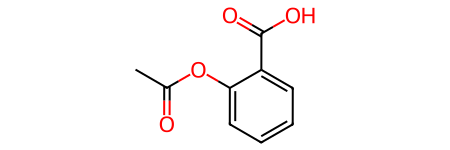

In [ ]:
smile = "CC(=O)OC1=CC=CC=C1C(=O)O"
mol = Chem.MolFromSmiles(smile)
mol

In [ ]:
smiles_list = [("2-acetyloxybenzoic acid","CC(=O)OC1=CC=CC=C1C(=O)O"),
               ("2-[4-(2-methylpropyl)phenyl]propanoic acid","CC(C)CC1=CC=C(C=C1)C(C)C(=O)O")]
for name, smiles in smiles_list:
  mol = Chem.MolFromSmiles(smiles)

  print(f"\nIUPAC NAME: {name}")
  print(f"molecular weight: {Descriptors.MolWt(mol):.2f}")


IUPAC NAME: 2-acetyloxybenzoic acid
molecular weight: 180.16

IUPAC NAME: 2-[4-(2-methylpropyl)phenyl]propanoic acid
molecular weight: 206.28


### Reading Multiple Chemical Structures
The RDKit also provides the ability to read molecules from common molecular structure formats.  In the code below we use the RDKit's **SDMolSupplier** feature to read molecules from an SD file. First, we'll download the file from GitHub.

In [ ]:
import requests
sd_file = requests.get("https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/data/example_compounds.sdf")
with open('compound_list.sdf' , 'w' , encoding = 'utf-8') as f:
  bytes_written = f.write(sd_file.text)

Here, we will be accessing the molecules as a list.

In [ ]:
molecules = [x for x in Chem.SDMolSupplier('compound_list.sdf')]

In [ ]:
molecules

Using the **mols2grid** feature to display the molecules in a grid.

In [ ]:
mols2grid.display(molecules, useSVG = True)

We can also read an SD file into a Pandas dataframe.

In [ ]:
df = PandasTools.LoadSDF("compound_list.sdf")

In [ ]:
mols2grid.display(df, mol_col="ROMol")